# Clustering — Comparação dos Algoritmos
Consolida métricas dos 3 métodos (K-Means, DBSCAN, Autoencoder+K-Means) e interpreta os resultados.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

## 1. Carregar métricas salvas pelos outros notebooks

In [2]:
def load_json(path, default=None):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        print(f'[AVISO] {path} não encontrado. Execute os notebooks anteriores primeiro.')
        return default or {}

km  = load_json('../dataset/metricas_kmeans.json')
db  = load_json('../dataset/metricas_dbscan.json')
ae  = load_json('../dataset/metricas_autoencoder.json')

print('K-Means:',    km)
print('DBSCAN:',     db)
print('Autoencoder:', ae)

K-Means: {'silhouette': 0.08681289884042187, 'davies_bouldin': 3.3046120280659452, 'k': 3}
DBSCAN: {'silhouette': None, 'davies_bouldin': None, 'n_clusters': 0, 'n_noise': 2000, 'eps': 2.0, 'min_samples': 5}
Autoencoder: {'silhouette': 0.3194197416305542, 'davies_bouldin': 1.3138208306985257, 'k': 3, 'latent_dim': 8}


## 2. Tabela comparativa

In [3]:
df_metricas = pd.DataFrame([
    {
        'Algoritmo':        'K-Means',
        'N° Clusters':      km.get('k', '-'),
        'Silhouette ↑':     km.get('silhouette'),
        'Davies-Bouldin ↓': km.get('davies_bouldin'),
        'Observação':       'Sem outliers'
    },
    {
        'Algoritmo':        'DBSCAN',
        'N° Clusters':      db.get('n_clusters', '-'),
        'Silhouette ↑':     db.get('silhouette'),
        'Davies-Bouldin ↓': db.get('davies_bouldin'),
        'Observação':       f"{db.get('n_noise', '?')} outliers detectados"
    },
    {
        'Algoritmo':        'Autoencoder + K-Means',
        'N° Clusters':      ae.get('k', '-'),
        'Silhouette ↑':     ae.get('silhouette'),
        'Davies-Bouldin ↓': ae.get('davies_bouldin'),
        'Observação':       f"Espaço latente: {ae.get('latent_dim', '?')}D"
    }
])

# Formatar métricas
df_metricas['Silhouette ↑']     = df_metricas['Silhouette ↑'].apply(
    lambda x: f'{x:.4f}' if x is not None else 'N/A')
df_metricas['Davies-Bouldin ↓'] = df_metricas['Davies-Bouldin ↓'].apply(
    lambda x: f'{x:.4f}' if x is not None else 'N/A')

df_metricas.set_index('Algoritmo', inplace=True)
display(df_metricas)

,N° Clusters,Silhouette ↑,Davies-Bouldin ↓,Observação
Algoritmo,,,,
K-Means,3,0.0868,3.3046,Sem outliers
DBSCAN,0,nan,nan,2000 outliers detectados
Autoencoder + K-Means,3,0.3194,1.3138,Espaço latente: 8D


## 3. Gráficos comparativos

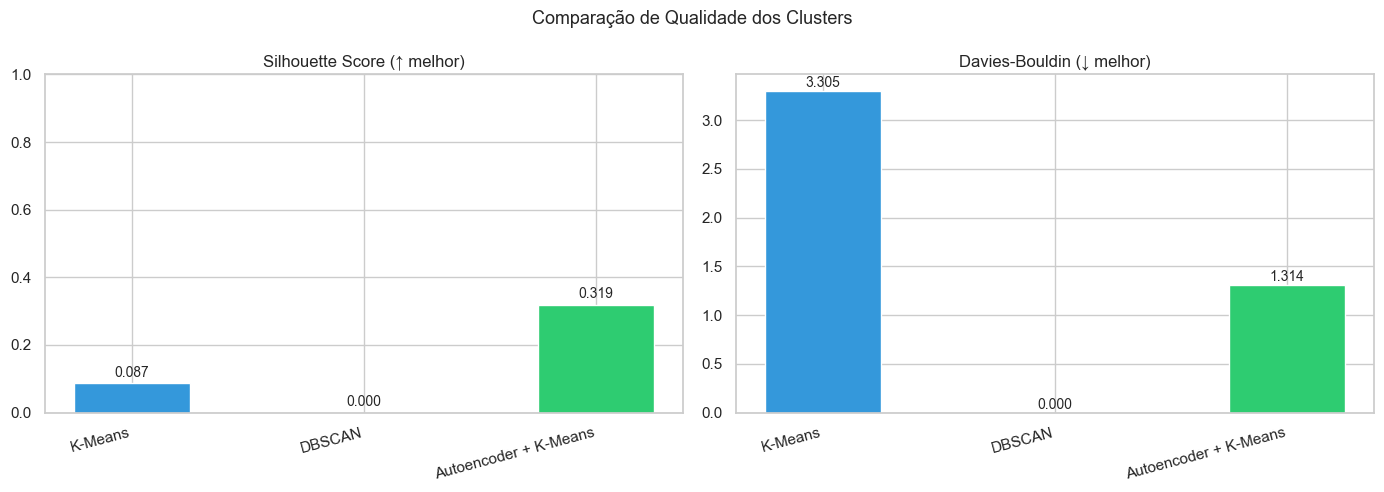

In [4]:
algoritmos = ['K-Means', 'DBSCAN', 'Autoencoder + K-Means']

sil_vals = [km.get('silhouette'), db.get('silhouette'), ae.get('silhouette')]
dbi_vals = [km.get('davies_bouldin'), db.get('davies_bouldin'), ae.get('davies_bouldin')]

# Substituir None por 0 para plotar
sil_vals = [v if v is not None else 0 for v in sil_vals]
dbi_vals = [v if v is not None else 0 for v in dbi_vals]

x = np.arange(len(algoritmos))
cores = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars0 = axes[0].bar(x, sil_vals, color=cores, edgecolor='white', width=0.5)
axes[0].set_title('Silhouette Score (↑ melhor)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(algoritmos, rotation=15, ha='right')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars0, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

bars1 = axes[1].bar(x, dbi_vals, color=cores, edgecolor='white', width=0.5)
axes[1].set_title('Davies-Bouldin (↓ melhor)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(algoritmos, rotation=15, ha='right')
for bar, val in zip(bars1, dbi_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparação de Qualidade dos Clusters', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Concordância entre algoritmos (Adjusted Rand Index)
Mede quanto dois agrupamentos concordam entre si (1 = idênticos, 0 = aleatório).

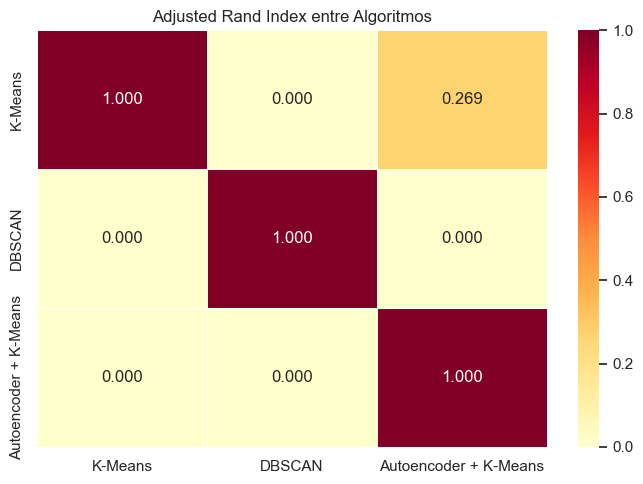

In [5]:
try:
    labels_km = np.load('../dataset/labels_kmeans.npy')
    labels_db = np.load('../dataset/labels_dbscan.npy')
    labels_ae = np.load('../dataset/labels_autoencoder.npy')

    # DBSCAN: outliers (-1) recebem cluster separado para cálculo do ARI
    labels_db_ari = labels_db.copy()
    labels_db_ari[labels_db_ari == -1] = labels_db_ari.max() + 1

    ari_km_db = adjusted_rand_score(labels_km, labels_db_ari)
    ari_km_ae = adjusted_rand_score(labels_km, labels_ae)
    ari_db_ae = adjusted_rand_score(labels_db_ari, labels_ae)

    df_ari = pd.DataFrame(
        [[1.0, ari_km_db, ari_km_ae],
         [ari_km_db, 1.0, ari_db_ae],
         [ari_db_ae, ari_db_ae, 1.0]],
        index=algoritmos, columns=algoritmos
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(df_ari, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5)
    plt.title('Adjusted Rand Index entre Algoritmos')
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f'[AVISO] {e} — execute os notebooks anteriores primeiro.')

## 5. Radar Chart — visão geral dos algoritmos

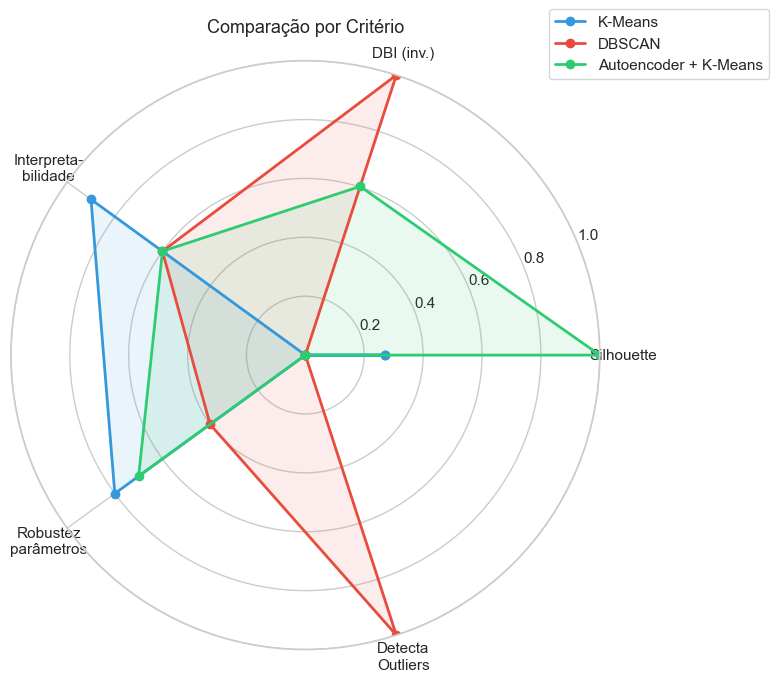

In [6]:
from matplotlib.patches import FancyArrowPatch
import matplotlib

# Critérios (todos normalizados de 0 a 1, onde 1 = melhor)
criterios = ['Silhouette', 'DBI (inv.)', 'Interpreta-\nbilidade', 'Robustez\nparâmetros', 'Detecta\nOutliers']
n = len(criterios)

# Pontuações subjetivas + métricas normalizadas
# Ajuste esses valores após ver seus resultados reais
max_sil = max(sil_vals) if max(sil_vals) > 0 else 1
max_dbi = max(dbi_vals) if max(dbi_vals) > 0 else 1

pontos = [
    # K-Means
    [sil_vals[0]/max_sil,           # Silhouette (normalizado)
     1 - dbi_vals[0]/max_dbi,       # DBI invertido
     0.9,                           # Interpretabilidade (alta)
     0.8,                           # Robustez de parâmetros (K é intuitivo)
     0.0],                          # Não detecta outliers
    # DBSCAN
    [sil_vals[1]/max_sil,
     1 - dbi_vals[1]/max_dbi,
     0.6,
     0.4,                           # Eps e min_samples são sensíveis
     1.0],                          # Detecta outliers
    # Autoencoder
    [sil_vals[2]/max_sil,
     1 - dbi_vals[2]/max_dbi,
     0.6,                           # Menos interpretável (caixa-preta)
     0.7,
     0.0]
]

angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = ['#3498db', '#e74c3c', '#2ecc71']

for i, (alg, pts, cor) in enumerate(zip(algoritmos, pontos, colors_radar)):
    vals = pts + pts[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=alg, color=cor)
    ax.fill(angles, vals, alpha=0.1, color=cor)

ax.set_thetagrids(np.degrees(angles[:-1]), criterios)
ax.set_ylim(0, 1)
ax.set_title('Comparação por Critério', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 6. Conclusão

| Critério | Melhor algoritmo |
|---|---|
| Qualidade dos clusters (Silhouette) | Veja tabela acima |
| Interpretabilidade dos resultados | **K-Means** |
| Detecção de perfis atípicos | **DBSCAN** |
| Captura de padrões não-lineares | **Autoencoder + K-Means** |

### Resposta à pergunta central
**Quais perfis de trabalhadores estão mais vulneráveis à IA?**

- Interprete cada cluster pelos campos `Automation_Risk`, `AI_Adoption_Level`, `Education_Level` e o percentual de `Replaced` dentro dele
- O cluster com maior `Automation_Risk=High`, baixa escolaridade e maior proporção de `Replaced` representa o grupo mais vulnerável
- O DBSCAN revela trabalhadores outliers — perfis raros que não se encaixam em nenhum padrão típico